## ridge and lasso regression

In [7]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = fetch_california_housing()

In [13]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [14]:
dataset = pd.DataFrame(df.data)

In [15]:
dataset.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [16]:
dataset.columns = df.feature_names

In [18]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [19]:
#now we have to know data.target. i.e; it is output values
df.target.shape

(20640,)

In [20]:
#add it in dataframe
dataset['price'] = df.target

In [21]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [27]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_regressor  = LinearRegression()
mse = cross_val_score(lin_regressor,x,y,scoring='neg_mean_squared_error',cv = 5)
mean_mse = np.mean(mse)
print(mean_mse)

-0.5582901717686554


In [32]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,65,100]}
ridge_regressor = GridSearchCV(ridge,parameters,scoring = 'neg_mean_squared_error',cv = 5)
ridge_regressor.fit(x,y)

,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,65


In [37]:
print(ridge_regressor.best_score_)
print(ridge_regressor.best_params_)

-0.5579315638374666
{'alpha': 65}


🧠 What is GridSearchCV?

GridSearchCV = Finding the best model parameters using cross-validation

🔍 Why do we need it?

Models have parameters (hyperparameters):

Example:

Ridge(alpha = ?)
Lasso(alpha = ?)

👉 Question:

What is the best value of alpha?

Instead of guessing, we use Grid Search

⚙️ How it works (Theory)
Step 1: Define parameter values
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
Step 2: Try ALL combinations

GridSearch will test:

alpha = 0.01
alpha = 0.1
alpha = 1
alpha = 10
alpha = 100
Step 3: For EACH value → apply Cross-Validation

For every alpha:

Score(alpha)=
k
1
	​

i=1
∑
k
	​

Error
i
	​


👉 Same concept you learned before!

🧠 Final formula idea

Best Parameter=argmin
θ
	​

(
k
1
	​

∑
i=1
k
	​

Loss
i
	​

(θ))

🔄 Full Process (Visualization)
For each parameter:
    For each fold:
        Train model
        Calculate error
    Compute average error
Pick parameter with lowest error

Are MSE and Cost Function the same?

👉 Short answer:

✅ MSE is a type of cost function
❌ But not all cost functions are MSE

🔍 What is a Cost Function?

A cost function is a general term for:
“A function that measures how wrong your model is”

📊 What is MSE?

MSE (Mean Squared Error) is one specific cost function:

MSE=
n
1
	​

∑
i=1
n
	​

(y
i
	​

−
y
^
	​

i
	​

)
2

👉 Used mainly in:

Linear Regression
Ridge Regression
Lasso Regression

In [36]:
#lasso regression:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
parameters =  {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,65,100]}
lasso_regressor = GridSearchCV(lasso,parameters,scoring = 'neg_mean_squared_error',cv = 5)

lasso_regressor.fit(x,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

C:\Users\sampa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.423e+02, tolerance: 2.228e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sampa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.590e+01, tolerance: 2.256e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\sampa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.603e+03, toleranc

{'alpha': 0.001}
-0.5582759293868991


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [40]:
prediction_lasso = lasso_regressor.predict(X_test)
prediction_ridge = ridge_regressor.predict(X_test)

C:\Users\sampa\AppData\Local\Temp\ipykernel_10868\1685645849.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - prediction_lasso)


<Axes: xlabel='price', ylabel='Density'>

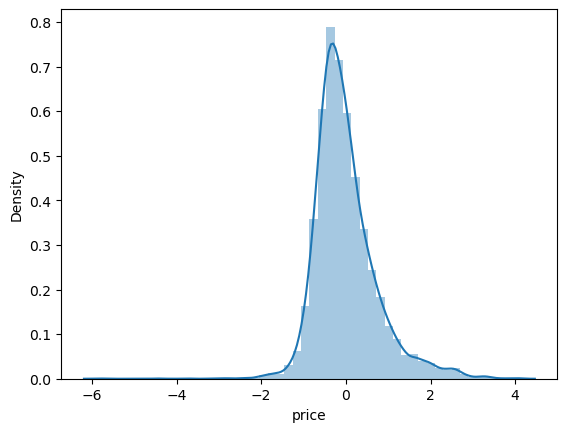

In [42]:
import seaborn as sns
sns.distplot(y_test - prediction_lasso)

C:\Users\sampa\AppData\Local\Temp\ipykernel_10868\665221327.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - prediction_ridge)


<Axes: xlabel='price', ylabel='Density'>

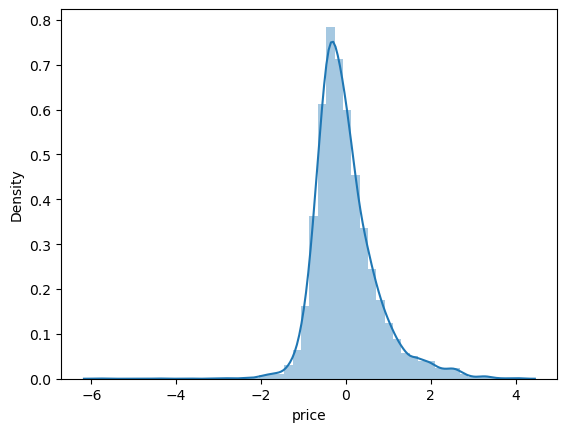

In [43]:
import seaborn as sns
sns.distplot(y_test - prediction_ridge)